In [1]:
import cudf as cf
import cupy as cp
import matplotlib.pyplot as plt

import optuna
# Use native XGBoost Dask API instead of dask-ml
import xgboost as xgb
# from dask_ml.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error       
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold

import plotly.express as px
from plotly.io import show

In [2]:
df_dropped = cf.read_csv("./tmp/df_39_no_na_dropped.csv")
df_filled = cf.read_csv("./tmp/df_39_no_na_filled.csv")

In [3]:
df_dropped.columns

Index(['route', 'trip_id', 'stopid', 'thrusteet', 'hour', 'day_of_week',
       'month', 'day_of_year', 'hour_sin', 'hour_cos', 'day_of_week_sin',
       'day_of_week_cos', 'delay_seconds', 'Climate ID', 'Temp (°C)',
       'Dew Point Temp (°C)', 'Rel Hum (%)', 'Wind Spd (km/h)',
       'Visibility (km)', 'Stn Press (kPa)', 'Precip. Amount (mm)', 'bound'],
      dtype='object')

In [4]:
df_dropped['delay_seconds'].describe()

count    6.186067e+06
mean    -6.134462e+01
std      7.033089e+02
min     -6.812163e+04
25%     -2.281870e+02
50%     -7.129100e+01
75%      4.800000e+01
max      3.644455e+04
Name: delay_seconds, dtype: float64

In [5]:
print(f"\nFeature shape(Filled): {df_filled.shape[0]:,} rows x {df_filled.shape[1]} columns")


Feature shape(Filled): 6,186,830 rows x 22 columns


In [6]:
print(f"\nFeature shape(Dropped): {df_dropped.shape[0]:,} rows x {df_dropped.shape[1]} columns")


Feature shape(Dropped): 6,186,067 rows x 22 columns


## EDA

Correlation Analysis

In [7]:
## correlation analysis of features with the target variable and show it in table
# remove thrusteet
df_corr = df_dropped.drop(columns=['thrusteet','route', 'trip_id']).to_pandas()  # Convert to pandas for correlation analysis
correlation_matrix = df_corr.corr(method='pearson')
target_correlation = correlation_matrix['delay_seconds'].drop('delay_seconds')  
print("Correlation of features with delay_seconds:")
print(target_correlation.sort_values(ascending=False))
# Visualize the correlation of features with the target variable using a bar chart
correlation_df = target_correlation.reset_index()
correlation_df.columns = ['Correlation', 'Feature']
fig = px.bar(correlation_df, x='Feature', y='Correlation', title='Correlation of Features with delay_seconds')
show(fig)

Correlation of features with delay_seconds:
day_of_year            0.049750
month                  0.048217
hour_cos               0.037903
day_of_week_sin        0.030492
hour_sin               0.021129
Rel Hum (%)            0.013591
bound                  0.010762
Dew Point Temp (°C)    0.007732
stopid                 0.007429
Visibility (km)        0.004391
Temp (°C)              0.002026
Precip. Amount (mm)   -0.002472
day_of_week           -0.003602
Wind Spd (km/h)       -0.005677
hour                  -0.007890
Stn Press (kPa)       -0.015633
day_of_week_cos       -0.031716
Climate ID                  NaN
Name: delay_seconds, dtype: float64


#### Delay By Hour

In [8]:
# delay by hour with > 0 delay seconds
hour_counts = df_dropped[df_dropped['delay_seconds'] > 0]['hour'].value_counts().sort_index()
hour_data = cf.DataFrame({'Hour': hour_counts.index, 'Count': hour_counts.values})
fig = px.bar(hour_data, x='Hour', y='Count', title='Delay Incidents by Hour of the Day', color='Hour')
fig.update_layout(xaxis_title='Hour of the Day', yaxis_title='Count')
fig.show()

In [9]:
# delay by week with > 0 delay seconds
day_counts = df_dropped[df_dropped['delay_seconds'] > 0]['day_of_week'].value_counts().sort_index()
day_order = ['Sunday', 'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday']
day_data = cf.DataFrame({'Day of the Week': day_order, 'Count': day_counts})

fig = px.bar(day_data, x='Day of the Week', y='Count', title='Delay Incidents by Day of the Week', color='Day of the Week')
fig.update_layout(xaxis_title='Day of the Week', yaxis_title='Count')

fig.show()

In [10]:
# delay by month with > 0 delay seconds
month_counts = df_dropped[df_dropped['delay_seconds'] > 0]['month'].value_counts().sort_index()
month_order = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']

month_data = cf.DataFrame({'Month': month_order, 'Count': month_counts})

fig = px.pie(month_data, values='Count', names='Month', title='Frequency of Delays by Month',
             hole=0.4, color_discrete_sequence=px.colors.qualitative.Set2)
fig.update_traces(textinfo='percent+label', pull=[0.1, 0, 0, 0, 0, 0])

fig.show()

## Dropped

In [11]:
cp.get_default_memory_pool().free_all_blocks()

In [12]:
df_dropped_X = df_dropped.drop(columns=['delay_seconds', 'route', 'trip_id', 'thrusteet'])
df_dropped_y = df_dropped['delay_seconds']

In [13]:
X_train_dropped, X_test_dropped, y_train_dropped, y_test_dropped = train_test_split(
    df_dropped_X,
    df_dropped_y,
    test_size=0.2,
    random_state=42
)

print(f"\nTrain size: {len(X_train_dropped):,}")
print(f"Test size: {len(X_test_dropped):,}")


Train size: 4,948,853
Test size: 1,237,214


In [14]:
X_train_dropped.head()

,stopid,hour,day_of_week,month,day_of_year,hour_sin,hour_cos,day_of_week_sin,day_of_week_cos,Climate ID,Temp (°C),Dew Point Temp (°C),Rel Hum (%),Wind Spd (km/h),Visibility (km),Stn Press (kPa),Precip. Amount (mm),bound
1810883,9319,6.0,0.0,12.0,349.0,1.000000,6.123234e-17,0.000000,1.000000,6158731.0,-8.3,-11.0,81.0,11.0,24.1,100.46,0.0,0
491200,1039,4.0,6.0,10.0,278.0,0.866025,5.000000e-01,-0.781831,0.623490,6158731.0,16.3,15.3,94.0,3.0,24.1,100.14,0.0,0
2712929,7158,19.0,1.0,3.0,70.0,-0.965926,2.588190e-01,0.781831,0.623490,6158731.0,1.0,-6.4,58.0,15.0,24.1,99.21,0.0,0
516975,5593,18.0,0.0,10.0,279.0,-1.000000,-1.836970e-16,0.000000,1.000000,6158731.0,24.2,13.2,50.0,14.0,24.1,99.78,0.0,0
1726798,10133,3.0,2.0,12.0,344.0,0.707107,7.071068e-01,0.974928,-0.222521,6158731.0,0.1,-0.7,94.0,9.0,3.2,97.77,0.0,0


In [15]:
X_train_dropped = X_train_dropped.to_cupy()
y_train_dropped = y_train_dropped.to_cupy()
X_test_dropped = X_test_dropped.to_cupy()
y_test_dropped = y_test_dropped.to_cupy()

In [16]:
# Define Optuna objective function for hyperparameter tuning
import numpy as np
def objective(trial):
    """Optuna objective function to minimize RMSE using native XGBoost Dask API"""
    
    # Define hyperparameter search space
    params = {
        'objective': 'reg:squarederror',
        'tree_method': 'hist',
        'device': 'cuda',
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'n_estimators': trial.suggest_int('n_estimators', 10_000,15_000, step=1000),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
    }
    
    n_samples = X_train_dropped.shape[0]
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    
    avg_r2_scores = np.zeros(kf.get_n_splits())
    
    # KFold.split only needs sample count — pass a range, no GPU→CPU data transfer
    for i, (train_index, val_index) in enumerate(kf.split(range(n_samples))):
        # Index cupy arrays directly with numpy indices
        dtrain = xgb.QuantileDMatrix(X_train_dropped[train_index], label=y_train_dropped[train_index])
        dval = xgb.QuantileDMatrix(X_train_dropped[val_index], label=y_train_dropped[val_index], ref=dtrain)

        model = xgb.train(params, dtrain, evals=[(dval, 'eval')], 
                      verbose_eval=False, early_stopping_rounds=100)
    
        # Make predictions (returns numpy array)
        y_pred = model.predict(dval)
    
        # Convert only the fold's labels to numpy for RMSE calculation
        y_fold = y_train_dropped[val_index].get()
        r2_square = r2_score(y_fold, y_pred)
        avg_r2_scores[i] = r2_square

    # Return average R2 score across folds
    return float(np.mean(avg_r2_scores))

print("Objective function defined with native XGBoost and Optuna GPU")

Objective function defined with native XGBoost and Optuna GPU


In [17]:
# Run Optuna hyperparameter optimization
print("Starting Optuna hyperparameter optimization...")
print("XGBoost will use GPU acceleration, and Optuna will run trials sequentially to maximize GPU utilization.")
print("This may take a while...\n")


# Create study with DaskStorage
study = optuna.create_study(
    direction='maximize',  # Minimize R2
    study_name='xgboost_delay_prediction',
    sampler=optuna.samplers.TPESampler(seed=42),
)

# Run optimization sequentially (XGBoost Dask handles parallelization internally)
n_trials = 50  # Total number of trials

print(f"Running {n_trials} trials...")

# Run sequential optimization - each trial uses Dask cluster efficiently
study.optimize(objective, n_trials=n_trials, show_progress_bar=True)

print("\n" + "="*60)
print("OPTIMIZATION COMPLETE!")
print("="*60)
print(f"\nBest trial: #{study.best_trial.number}")
print(f"Best RMSE: {study.best_value:.4f}")
print("\nBest hyperparameters:")
for key, value in study.best_params.items():
    print(f"  {key}: {value}")

[I 2026-03-17 22:39:48,448] A new study created in memory with name: xgboost_delay_prediction


Starting Optuna hyperparameter optimization...
XGBoost will use GPU acceleration, and Optuna will run trials sequentially to maximize GPU utilization.
This may take a while...

Running 50 trials...


  0%|          | 0/50 [00:00<?, ?it/s]

/home/artificialstupidity/ttc-bus-delay-prediction/.venv/lib/python3.12/site-packages/xgboost/callback.py:385: UserWarning:

[22:39:48] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "n_estimators" } are not used.


/home/artificialstupidity/ttc-bus-delay-prediction/.venv/lib/python3.12/site-packages/xgboost/callback.py:385: UserWarning:

[22:39:49] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "n_estimators" } are not used.


/home/artificialstupidity/ttc-bus-delay-prediction/.venv/lib/python3.12/site-packages/xgboost/callback.py:385: UserWarning:

[22:39:49] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "n_estimators" } are not used.


/home/artificialstupidity/ttc-bus-delay-prediction/.venv/lib/python3.12/site-packages/xgboost/callback.py:385: UserWarning:

[22:39:50] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "n_estimators" } are not used.


/home/artificialstupidity/ttc-bus-delay-prediction/.venv/lib/pyt

[I 2026-03-17 22:39:50,547] Trial 0 finished with value: 0.801444352020512 and parameters: {'max_depth': 5, 'learning_rate': 0.2536999076681772, 'n_estimators': 14000, 'subsample': 0.8394633936788146, 'colsample_bytree': 0.6624074561769746}. Best is trial 0 with value: 0.801444352020512.


...

[I 2026-03-17 22:41:23,687] Trial 47 finished with value: 0.8497825257488081 and parameters: {'max_depth': 10, 'learning_rate': 0.18386091129765564, 'n_estimators': 15000, 'subsample': 0.8314228670236208, 'colsample_bytree': 0.6226114537107725}. Best is trial 44 with value: 0.8793804501453228.


/home/artificialstupidity/ttc-bus-delay-prediction/.venv/lib/python3.12/site-packages/xgboost/callback.py:385: UserWarning:

[22:41:23] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "n_estimators" } are not used.


/home/artificialstupidity/ttc-bus-delay-prediction/.venv/lib/python3.12/site-packages/xgboost/callback.py:385: UserWarning:

[22:41:24] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "n_estimators" } are not used.


/home/artificialstupidity/ttc-bus-delay-prediction/.venv/lib/python3.12/site-packages/xgboost/callback.py:385: UserWarning:

[22:41:24] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "n_estimators" } are not used.


/home/artificialstupidity/ttc-bus-delay-prediction/.venv/lib/python3.12/site-packages/xgboost/callback.py:385: UserWarning:

[22:41:25] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "n_estimators" } are not used.


/home/artificialstupidity/ttc-bus-delay-prediction/.venv/lib/pyt

[I 2026-03-17 22:41:25,948] Trial 48 finished with value: 0.8610471559299574 and parameters: {'max_depth': 9, 'learning_rate': 0.22241520757903166, 'n_estimators': 15000, 'subsample': 0.7666075726455418, 'colsample_bytree': 0.6301418472210345}. Best is trial 44 with value: 0.8793804501453228.


/home/artificialstupidity/ttc-bus-delay-prediction/.venv/lib/python3.12/site-packages/xgboost/callback.py:385: UserWarning:

[22:41:26] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "n_estimators" } are not used.


/home/artificialstupidity/ttc-bus-delay-prediction/.venv/lib/python3.12/site-packages/xgboost/callback.py:385: UserWarning:

[22:41:26] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "n_estimators" } are not used.


/home/artificialstupidity/ttc-bus-delay-prediction/.venv/lib/python3.12/site-packages/xgboost/callback.py:385: UserWarning:

[22:41:27] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "n_estimators" } are not used.


/home/artificialstupidity/ttc-bus-delay-prediction/.venv/lib/python3.12/site-packages/xgboost/callback.py:385: UserWarning:

[22:41:27] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "n_estimators" } are not used.


/home/artificialstupidity/ttc-bus-delay-prediction/.venv/lib/pyt

[I 2026-03-17 22:41:28,755] Trial 49 finished with value: 0.8249501920696201 and parameters: {'max_depth': 10, 'learning_rate': 0.1531253402715371, 'n_estimators': 15000, 'subsample': 0.8041748162229982, 'colsample_bytree': 0.649931894460615}. Best is trial 44 with value: 0.8793804501453228.

OPTIMIZATION COMPLETE!

Best trial: #44
Best RMSE: 0.8794

Best hyperparameters:
  max_depth: 10
  learning_rate: 0.2959866057585675
  n_estimators: 15000
  subsample: 0.7792869062527739
  colsample_bytree: 0.6238819251173411


In [18]:
study.best_params

{'max_depth': 10,
 'learning_rate': 0.2959866057585675,
 'n_estimators': 15000,
 'subsample': 0.7792869062527739,
 'colsample_bytree': 0.6238819251173411}

In [19]:
cp.get_default_memory_pool().free_all_blocks()

In [20]:
# Train final model with best parameters using native XGBoost Dask API
print("Training final model with best hyperparameters...")
print("="*60)

# Get best parameters
best_params = study.best_params.copy()
best_params['objective'] = 'reg:squarederror'
best_params['tree_method'] = 'hist'  # Required for Dask

# Create QuantileDMatrix for training
dtrain = xgb.QuantileDMatrix(X_train_dropped, y_train_dropped)

# Train final model using native Dask XGBoost
output = xgb.train(
    best_params,
    dtrain,
)

Training final model with best hyperparameters...


/home/artificialstupidity/ttc-bus-delay-prediction/.venv/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning:

[22:41:28] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "n_estimators" } are not used.




In [21]:
dtest = xgb.QuantileDMatrix(X_test_dropped)
y_pred_dropped = output.predict(dtest)

In [22]:
rmse_dropped = np.sqrt(mean_squared_error(y_test_dropped.get(), y_pred_dropped))
r2_dropped = r2_score(y_test_dropped.get(), y_pred_dropped)
mae_dropped = mean_absolute_error(y_test_dropped.get(), y_pred_dropped)
print("Final Model Performance on Test Set:")
print(f"  RMSE: {rmse_dropped:.4f}")
print(f"  R²: {r2_dropped:.4f}")
print(f"  MAE: {mae_dropped:.4f}")

Final Model Performance on Test Set:
  RMSE: 245.5862
  R²: 0.8828
  MAE: 154.2054


In [23]:
output.get_score(importance_type='gain')

{'f0': 43563004.0,
 'f1': 36470744.0,
 'f2': 980048384.0,
 'f3': 391193952.0,
 'f4': 178826080.0,
 'f5': 44307240.0,
 'f6': 608448128.0,
 'f7': 67859328.0,
 'f8': 136073856.0,
 'f10': 818632448.0,
 'f11': 559448640.0,
 'f12': 201143824.0,
 'f13': 28185884.0,
 'f14': 6533860.0,
 'f15': 1664603520.0,
 'f16': 3163409.0,
 'f17': 6080503.5}

In [24]:
output.set_param({'device': 'cuda'})

In [25]:
import shap
shap_values = output.predict(dtrain, pred_contribs=True)
explainer = shap.TreeExplainer(output)
shap_values = explainer.shap_values(X_test_dropped)
feature_names = df_dropped_X.columns.tolist()

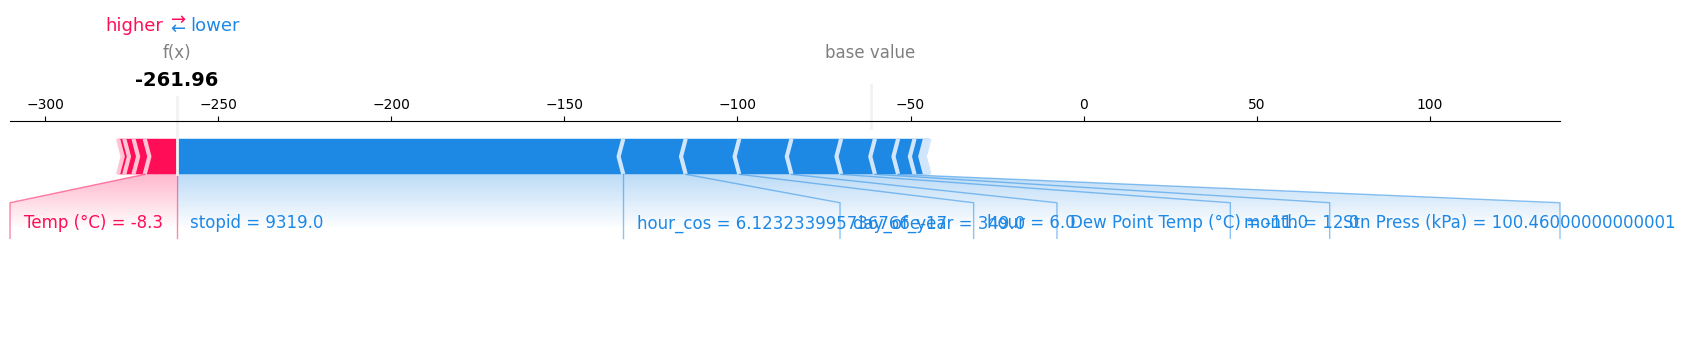

In [26]:
shap.force_plot(
    explainer.expected_value,
    shap_values[0, :],
    X_train_dropped[0, :].get(),
    feature_names=feature_names,
    matplotlib=True,
)

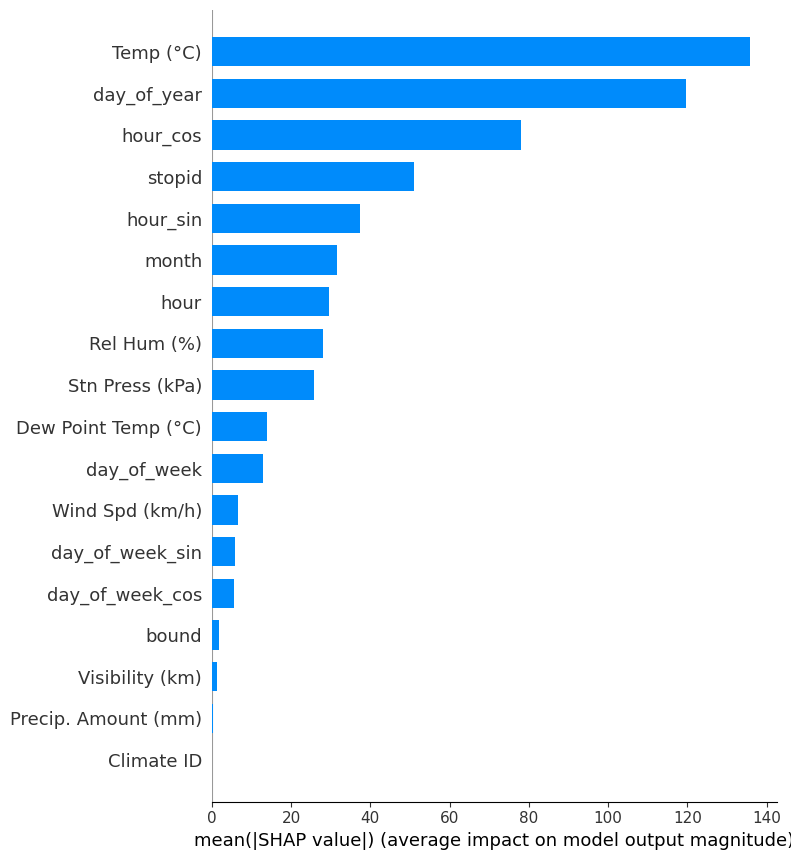

In [27]:
shap.summary_plot(shap_values, X_train_dropped, plot_type="bar", feature_names=feature_names)

## Filled

In [28]:
cp.get_default_memory_pool().free_all_blocks()

In [29]:
df_filled_X = df_filled.drop(columns=['delay_seconds', 'route', 'trip_id', 'thrusteet'])
df_filled_y = df_filled['delay_seconds']

In [30]:
X_train_filled, X_test_filled, y_train_filled, y_test_filled = train_test_split(
    df_filled_X,
    df_filled_y,
    test_size=0.2,
    random_state=42
)

In [31]:
X_train_filled = X_train_filled.to_cupy()
y_train_filled = y_train_filled.to_cupy()
X_test_filled = X_test_filled.to_cupy()
y_test_filled = y_test_filled.to_cupy()

In [32]:
# Define Optuna objective function for hyperparameter tuning
def objective(trial):
    """Optuna objective function to minimize RMSE using native XGBoost Dask API"""
    
    # Define hyperparameter search space
    params = {
        'objective': 'reg:squarederror',
        'tree_method': 'hist',
        'device': 'cuda',
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'n_estimators': trial.suggest_int('n_estimators', 10_000,15_000, step=1000),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
    }
    
    n_samples = X_train_filled.shape[0]
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    
    avg_r2_scores = np.zeros(kf.get_n_splits())
    
    # KFold.split only needs sample count — pass a range, no GPU→CPU data transfer
    for i, (train_index, val_index) in enumerate(kf.split(range(n_samples))):
        # Index cupy arrays directly with numpy indices
        dtrain = xgb.QuantileDMatrix(X_train_filled[train_index], label=y_train_filled[train_index])
        dval = xgb.QuantileDMatrix(X_train_filled[val_index], label=y_train_filled[val_index], ref=dtrain)

        model = xgb.train(params, dtrain, evals=[(dval, 'eval')], 
                      verbose_eval=False, early_stopping_rounds=100)
    
        # Make predictions (returns numpy array)
        y_pred = model.predict(dval)
    
        # Convert only the fold's labels to numpy for RMSE calculation
        y_fold = y_train_filled[val_index].get()
        r2_square = r2_score(y_fold, y_pred)
        avg_r2_scores[i] = r2_square

    # Return average R2 score across folds
    return float(np.mean(avg_r2_scores))

print("Objective function defined with native XGBoost and Optuna GPU")

Objective function defined with native XGBoost and Optuna GPU


In [33]:
# Create study with DaskStorage
study = optuna.create_study(
    direction='maximize',  # Minimize R2
    study_name='xgboost_delay_prediction',
    sampler=optuna.samplers.TPESampler(seed=42),
)

# Run optimization sequentially (XGBoost Dask handles parallelization internally)
n_trials = 50  # Total number of trials

print(f"Running {n_trials} trials...")

# Run sequential optimization - each trial uses Dask cluster efficiently
study.optimize(objective, n_trials=n_trials, show_progress_bar=True)

print("\n" + "="*60)
print("OPTIMIZATION COMPLETE!")
print("="*60)
print(f"\nBest trial: #{study.best_trial.number}")
print(f"Best RMSE: {study.best_value:.4f}")
print("\nBest hyperparameters:")
for key, value in study.best_params.items():
    print(f"  {key}: {value}")

[I 2026-03-17 22:41:49,506] A new study created in memory with name: xgboost_delay_prediction


Running 50 trials...


  0%|          | 0/50 [00:00<?, ?it/s]

/home/artificialstupidity/ttc-bus-delay-prediction/.venv/lib/python3.12/site-packages/xgboost/callback.py:385: UserWarning:

[22:41:49] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "n_estimators" } are not used.


/home/artificialstupidity/ttc-bus-delay-prediction/.venv/lib/python3.12/site-packages/xgboost/callback.py:385: UserWarning:

[22:41:50] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "n_estimators" } are not used.


/home/artificialstupidity/ttc-bus-delay-prediction/.venv/lib/python3.12/site-packages/xgboost/callback.py:385: UserWarning:

[22:41:50] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "n_estimators" } are not used.


/home/artificialstupidity/ttc-bus-delay-prediction/.venv/lib/python3.12/site-packages/xgboost/callback.py:385: UserWarning:

[22:41:50] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "n_estimators" } are not used.


/home/artificialstupidity/ttc-bus-delay-prediction/.venv/lib/pyt

[I 2026-03-17 22:41:51,379] Trial 0 finished with value: 0.8036415497625267 and parameters: {'max_depth': 5, 'learning_rate': 0.2536999076681772, 'n_estimators': 14000, 'subsample': 0.8394633936788146, 'colsample_bytree': 0.6624074561769746}. Best is trial 0 with value: 0.8036415497625267.


...

[I 2026-03-17 22:43:37,767] Trial 47 finished with value: 0.8414199671111767 and parameters: {'max_depth': 10, 'learning_rate': 0.15049628849838045, 'n_estimators': 11000, 'subsample': 0.767038208137396, 'colsample_bytree': 0.9543233639741979}. Best is trial 43 with value: 0.8780662841278261.


/home/artificialstupidity/ttc-bus-delay-prediction/.venv/lib/python3.12/site-packages/xgboost/callback.py:385: UserWarning:

[22:43:38] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "n_estimators" } are not used.


/home/artificialstupidity/ttc-bus-delay-prediction/.venv/lib/python3.12/site-packages/xgboost/callback.py:385: UserWarning:

[22:43:38] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "n_estimators" } are not used.


/home/artificialstupidity/ttc-bus-delay-prediction/.venv/lib/python3.12/site-packages/xgboost/callback.py:385: UserWarning:

[22:43:39] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "n_estimators" } are not used.


/home/artificialstupidity/ttc-bus-delay-prediction/.venv/lib/python3.12/site-packages/xgboost/callback.py:385: UserWarning:

[22:43:39] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "n_estimators" } are not used.


/home/artificialstupidity/ttc-bus-delay-prediction/.venv/lib/pyt

[I 2026-03-17 22:43:40,198] Trial 48 finished with value: 0.21061872464030068 and parameters: {'max_depth': 9, 'learning_rate': 0.01400985974088348, 'n_estimators': 10000, 'subsample': 0.7977133998254688, 'colsample_bytree': 0.9791515851007669}. Best is trial 43 with value: 0.8780662841278261.


/home/artificialstupidity/ttc-bus-delay-prediction/.venv/lib/python3.12/site-packages/xgboost/callback.py:385: UserWarning:

[22:43:40] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "n_estimators" } are not used.


/home/artificialstupidity/ttc-bus-delay-prediction/.venv/lib/python3.12/site-packages/xgboost/callback.py:385: UserWarning:

[22:43:41] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "n_estimators" } are not used.


/home/artificialstupidity/ttc-bus-delay-prediction/.venv/lib/python3.12/site-packages/xgboost/callback.py:385: UserWarning:

[22:43:41] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "n_estimators" } are not used.


/home/artificialstupidity/ttc-bus-delay-prediction/.venv/lib/python3.12/site-packages/xgboost/callback.py:385: UserWarning:

[22:43:42] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "n_estimators" } are not used.


/home/artificialstupidity/ttc-bus-delay-prediction/.venv/lib/pyt

[I 2026-03-17 22:43:42,887] Trial 49 finished with value: 0.8768448125981868 and parameters: {'max_depth': 10, 'learning_rate': 0.23874223879463694, 'n_estimators': 13000, 'subsample': 0.8885968923531297, 'colsample_bytree': 0.901251016136662}. Best is trial 43 with value: 0.8780662841278261.

OPTIMIZATION COMPLETE!

Best trial: #43
Best RMSE: 0.8781

Best hyperparameters:
  max_depth: 10
  learning_rate: 0.24387572607873384
  n_estimators: 11000
  subsample: 0.7929855724255178
  colsample_bytree: 0.9758243883209662


In [34]:
study.best_params

{'max_depth': 10,
 'learning_rate': 0.24387572607873384,
 'n_estimators': 11000,
 'subsample': 0.7929855724255178,
 'colsample_bytree': 0.9758243883209662}

In [35]:
cp.get_default_memory_pool().free_all_blocks()

In [36]:
# Train final model with best parameters using native XGBoost Dask API
print("Training final model with best hyperparameters...")
print("="*60)

# Get best parameters
best_params = study.best_params.copy()
best_params['objective'] = 'reg:squarederror'
best_params['tree_method'] = 'hist'  # Required for Dask

# Create QuantileDMatrix for training
dtrain = xgb.QuantileDMatrix(X_train_filled, y_train_filled)

# Train final model using native Dask XGBoost
output = xgb.train(
    best_params,
    dtrain,
)

Training final model with best hyperparameters...


/home/artificialstupidity/ttc-bus-delay-prediction/.venv/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning:

[22:43:43] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "n_estimators" } are not used.




In [37]:
dtest = xgb.QuantileDMatrix(X_test_filled)
y_pred_filled = output.predict(dtest)

In [38]:
rmse_filled = np.sqrt(mean_squared_error(y_test_filled.get(), y_pred_filled))
r2_filledd = r2_score(y_test_filled.get(), y_pred_filled)
mae_filled = mean_absolute_error(y_test_filled.get(), y_pred_filled)
print("Final Model Performance on Test Set:")
print(f"  RMSE: {rmse_filled:.4f}")
print(f"  R²: {r2_filledd:.4f}")
print(f"  MAE: {mae_filled:.4f}")

Final Model Performance on Test Set:
  RMSE: 248.1067
  R²: 0.8754
  MAE: 153.6508


In [39]:
output.get_score(importance_type='gain')

{'f0': 31910926.0,
 'f1': 39541652.0,
 'f2': 363649792.0,
 'f3': 170613344.0,
 'f4': 312333440.0,
 'f5': 123700376.0,
 'f6': 198849312.0,
 'f7': 20448370.0,
 'f8': 494108096.0,
 'f10': 4145196544.0,
 'f11': 596963072.0,
 'f12': 117904408.0,
 'f13': 39418784.0,
 'f14': 10331386.0,
 'f15': 114204032.0,
 'f16': 4677404.5,
 'f17': 12759850.0}

In [40]:
output.set_param({'device': 'cuda'})

In [41]:
shap_values = output.predict(dtrain, pred_contribs=True)
explainer = shap.TreeExplainer(output)
shap_values = explainer.shap_values(X_test_filled)
feature_names = df_filled_X.columns.tolist()

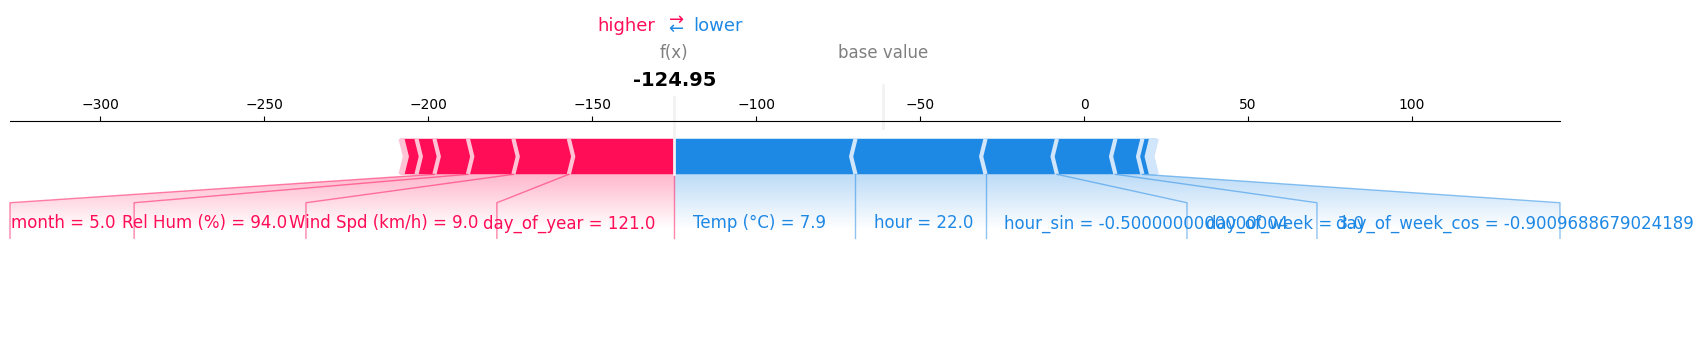

In [42]:
shap.force_plot(
    explainer.expected_value,
    shap_values[0, :],
    X_train_filled[0, :].get(),
    feature_names=feature_names,
    matplotlib=True,
)

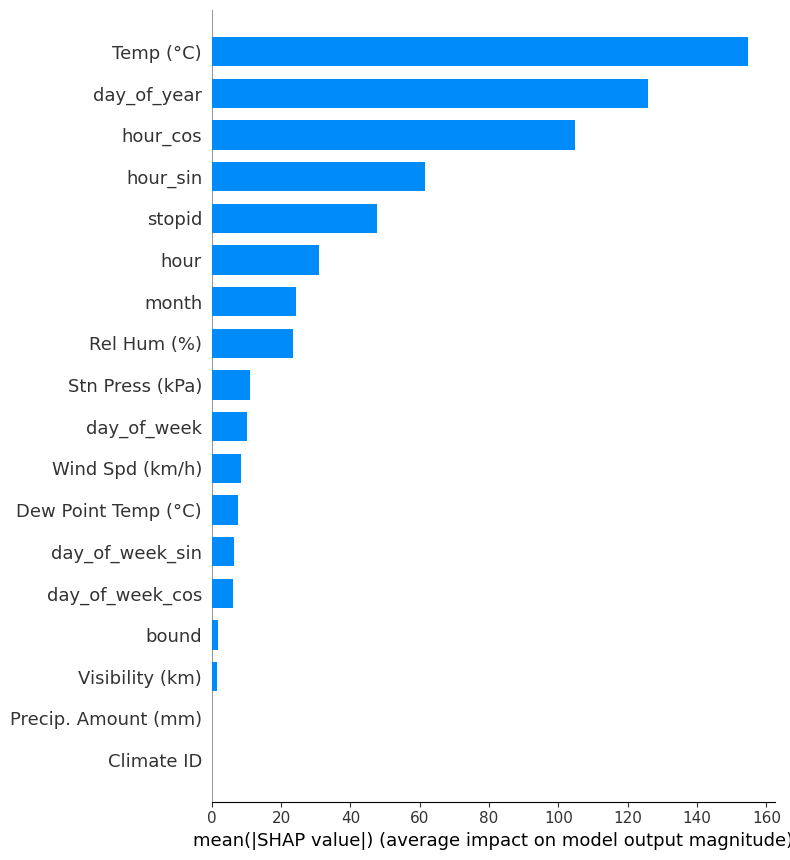

In [43]:
shap.summary_plot(shap_values, X_train_filled, plot_type="bar", feature_names=feature_names)

### Dropped Vs Filled Model Comparision

In [44]:
from plotly.subplots import make_subplots
import plotly.graph_objects as go

rmse = [rmse_dropped, rmse_filled]
r2 = [r2_dropped, r2_filledd]
mae = [mae_dropped, mae_filled]
models = ['Dropped Features Model', 'Filled Features Model']

# using 1,2 subplot
fig = make_subplots(rows=1, cols=3, subplot_titles=('RMSE', 'R²', 'MAE'))
fig.add_trace(go.Bar(x=models, y=rmse), row=1, col=1)
fig.add_trace(go.Bar(x=models, y=r2), row=1, col=2)
fig.add_trace(go.Bar(x=models, y=mae), row=1, col=3)
fig.update_layout(title_text='Model Performance Comparison', showlegend=False)
fig.update_xaxes(title_text='Model', row=1, col=1)
fig.update_xaxes(title_text='Model', row=1, col=2)
fig.update_yaxes(title_text='RMSE', row=1, col=1)
fig.update_yaxes(title_text='R²', row=1, col=2)
fig.update_yaxes(title_text='MAE', row=1, col=3)

fig.show()